# Customer Retention Intelligence — Iteration 1

This notebook builds a **working baseline customer retention model**.

By the end, you will:
- load the customer dataset
- inspect and clean the data
- prepare features
- train a baseline classification model
- evaluate it with metrics better than accuracy alone
- save the trained model for later iterations

> Dataset expected at: `../data/Customer_Churn_Dataset.xlsx`  
> Sheet expected: `01 Churn-Dataset`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

import joblib


## 1. Load the dataset

In [2]:
df = pd.read_excel(
    "../data/Customer_Churn_Dataset.xlsx",
    sheet_name="01 Churn-Dataset"
)

df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,numAdminTickets,numTechTickets,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.5,0,0,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,0,0,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,3,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,0,0,Yes


## 2. Basic data inspection

In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


Shape: (7043, 23)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'numAdminTickets', 'numTechTickets', 'Churn']


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
print(df["Churn"].value_counts())
print()
print(df["Churn"].value_counts(normalize=True))


Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [6]:
df.isnull().sum().sort_values(ascending=False)


customerID          0
TechSupport         0
numTechTickets      0
numAdminTickets     0
TotalCharges        0
MonthlyCharges      0
PaymentMethod       0
PaperlessBilling    0
Contract            0
StreamingMovies     0
StreamingTV         0
DeviceProtection    0
gender              0
OnlineBackup        0
OnlineSecurity      0
InternetService     0
MultipleLines       0
PhoneService        0
tenure              0
Dependents          0
Partner             0
SeniorCitizen       0
Churn               0
dtype: int64

## 3. Inspect data types

`TotalCharges` sometimes appears as text in versions of this dataset, so we check and clean it safely.


In [7]:
df.dtypes


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
numAdminTickets       int64
numTechTickets        int64
Churn                object
dtype: object

In [8]:
print("TotalCharges dtype:", df["TotalCharges"].dtype)
print(df["TotalCharges"].head(20))


TotalCharges dtype: object
0       29.85
1      1889.5
2      108.15
3     1840.75
4      151.65
5       820.5
6      1949.4
7       301.9
8     3046.05
9     3487.95
10     587.45
11      326.8
12     5681.1
13     5036.3
14    2686.05
15    7895.15
16    1022.95
17    7382.25
18     528.35
19     1862.9
Name: TotalCharges, dtype: object


## 4. Clean the dataset

In [9]:
# Convert TotalCharges to numeric.
# Any non-numeric values become NaN.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Missing values in TotalCharges after conversion:")
print(df["TotalCharges"].isnull().sum())


Missing values in TotalCharges after conversion:
11


In [10]:
# Fill missing TotalCharges values using the median.
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

print("Remaining missing values:")
print(df.isnull().sum().sum())


Remaining missing values:
0


## 5. Remove columns that should not be used as predictors

`customerID` identifies a customer but does not describe customer behavior, so we remove it from the model.


In [19]:
df_model = df.drop(columns=["customerID"]).copy()

df_model.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,numAdminTickets,numTechTickets,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,One year,No,Mailed check,56.95,1889.50,0,0,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,0,0,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,3,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,0,0,Yes


## 6. Convert the target to numeric

In [20]:
df_model["Churn"] = df_model["Churn"].map({
    "No": 0,
    "Yes": 1
})

df_model["Churn"].value_counts()


Churn
0    5174
1    1869
Name: count, dtype: int64

## 7. Separate features and target

In [21]:
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)


Feature shape: (7043, 21)
Target shape: (7043,)


## 8. Identify numerical and categorical features

In [22]:
numeric_features = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)


Numeric features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'numAdminTickets', 'numTechTickets']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 9. Train-test split

We use `stratify=y` so the churn proportion stays similar in both train and test sets.


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining churn rate:", y_train.mean())
print("Test churn rate:", y_test.mean())


Training set: (5634, 21)
Test set: (1409, 21)

Training churn rate: 0.2653532126375577
Test churn rate: 0.2654364797728886


## 10. Build preprocessing pipeline

In [24]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


## 11. Build the baseline model

We start with **Logistic Regression** because it is:
- strong as a baseline
- fast
- easy to explain
- commonly used for churn/retention problems


In [25]:
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

baseline_model


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges',
                                                   'numAdminTickets',
                                                   'numTechTickets']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

## 12. Train the model

In [26]:
baseline_model.fit(X_train, y_train)

print("Model training complete.")


Model training complete.


## 13. Make predictions

In [27]:
y_pred = baseline_model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:, 1]

print("Predictions generated:", len(y_pred))


Predictions generated: 1409


## 14. Evaluate the model

Because churn is imbalanced, we look at:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC


In [28]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")
print(f"ROC-AUC:   {roc_auc:.3f}")


Accuracy:  0.857
Precision: 0.757
Recall:    0.682
F1-score:  0.717
ROC-AUC:   0.927


In [ ]:
print(classification_report(y_test, y_pred))


## 15. Confusion matrix

In [29]:
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Stay", "Actual Churn"],
    columns=["Predicted Stay", "Predicted Churn"]
)

cm_df


,Predicted Stay,Predicted Churn
Actual Stay,953,82
Actual Churn,119,255


## 16. ROC curve

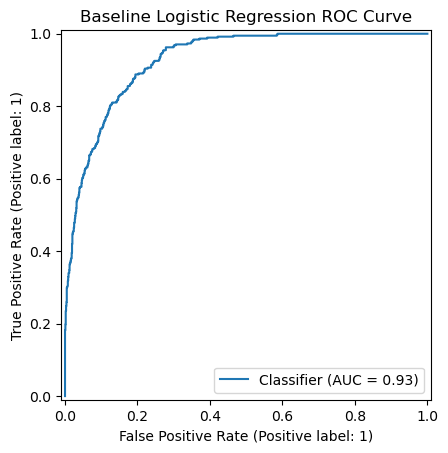

In [30]:
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("Baseline Logistic Regression ROC Curve")
plt.show()


## 17. Create customer-level retention risk output

This is the first step toward our final product.


In [31]:
results = X_test.copy()

results["actual_churn"] = y_test.values
results["predicted_churn"] = y_pred
results["churn_probability"] = y_prob

results["risk_level"] = pd.cut(
    results["churn_probability"],
    bins=[-0.01, 0.30, 0.60, 1.00],
    labels=["Low", "Medium", "High"]
)

results[
    ["churn_probability", "risk_level", "actual_churn", "predicted_churn"]
].sort_values(
    by="churn_probability",
    ascending=False
).head(20)


,churn_probability,risk_level,actual_churn,predicted_churn
2877,0.999129,High,1,1
4792,0.996460,High,1,1
2012,0.993247,High,1,1
3047,0.991220,High,1,1
402,0.990929,High,1,1
1171,0.989344,High,1,1
2798,0.989286,High,1,1
2206,0.988318,High,1,1
6593,0.987636,High,1,1
4594,0.986170,High,1,1


## 18. Save the baseline model

In [32]:
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    baseline_model,
    "../models/baseline_retention_model.joblib"
)

print("Saved to ../models/baseline_retention_model.joblib")


Saved to ../models/baseline_retention_model.joblib
